SYRIA TEL COMMUNICATION CHURN PREDICTION

PROJECT OVERVIEW

This notebook aims to predict customer churn for SyriaTel, a telecommunications company in Syria. The project uses historical customer data to identify patterns and build predictive models (Logistic Regression and Decision Tree) to help the business proactively reduce churn, retain revenue, and improve customer satisfaction.

1.BUSINESS UNDERSTANDING

Business Objective/Problem: Predict whether a customer will stop doing business with SyriaTel “soon” (binary: churn = 1, stay = 0).

Audience: Telecom business managers who want to reduce customer churn and retain revenue.

Key question: Are there predictable patterns ( usage, customer service calls,ETC) that signal churn?. These will be our key drivers.

Compare model performance(Logistic Regression vs Decision Tree)

Provide actionable business recommendations based on insights


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE


2.DATA UNDERSTANDING

In [5]:
df = pd.read_csv("bigml_59c28831336c6604c800002a.csv")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [14]:
#checking missing values
MV = df.isnull().sum()
MV

state                     0
account_length            0
international_plan        0
voice_mail_plan           0
number_vmail_messages     0
total_day_minutes         0
total_day_calls           0
total_day_charge          0
total_eve_minutes         0
total_eve_calls           0
total_eve_charge          0
total_night_minutes       0
total_night_calls         0
total_night_charge        0
total_intl_minutes        0
total_intl_calls          0
total_intl_charge         0
customer_service_calls    0
churn                     0
dtype: int64

In [15]:
#check for duplicates
df.duplicated().sum()

0

In [7]:
df.columns

Index(['state', 'account length', 'area code', 'phone number',
       'international plan', 'voice mail plan', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls', 'churn'],
      dtype='object')

In [12]:
churn_counts = df['churn'].value_counts()
churn_counts

churn
False    2850
True      483
Name: count, dtype: int64

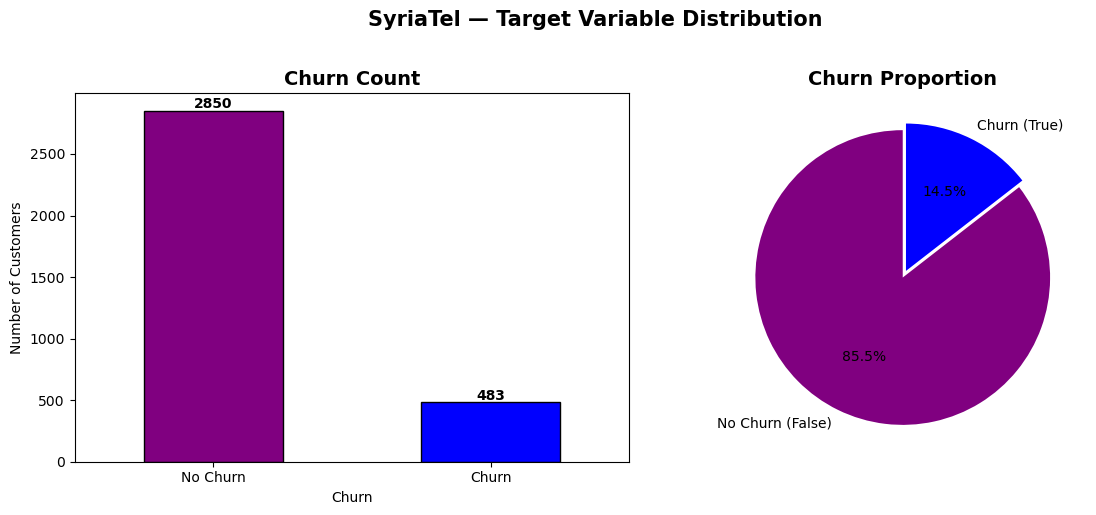

In [44]:
# Plot the target variable distribution
# Create a figure with 1 row and 2 subplots (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot churn counts as a bar chart
churn_counts.plot(
    kind='bar', 
    ax=axes[0], 
    color=['purple', 'blue'],   
    edgecolor='black'                
)
# title and axis labels for the bar chart
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')

# x-axis tick labels
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

# Add labels on top of each bar
for i, v in enumerate(churn_counts):
    axes[0].text(
        i, v + 20,           
        str(v),              
        ha='center',         
        fontweight='bold'
    )

# Plot churn distribution as a pie chart
axes[1].pie(
    churn_counts,
    labels=['No Churn (False)', 'Churn (True)'],  
    autopct='%1.1f%%',                          
    colors=['purple', 'blue'],              
    startangle=90,                               
    explode=(0, 0.05)                            
)
# Set title for the pie chart
axes[1].set_title('Churn Proportion', fontsize=14, fontweight='bold')
# Add an overall title for the entire figure
plt.suptitle(
    'SyriaTel — Target Variable Distribution', 
    fontsize=15, 
    fontweight='bold', 
    y=1.02
)

plt.tight_layout()
plt.show()

KEY INSIGHTS: 
There is a significant class imbalance.
we will have to use SMOTE and adjust class weights so the model does not predict no churn all the time.
while we have a retention rate of 85%, a 14.5% churn rate is still significant.

In [ ]:
DATA CLEANING/PREPARATION

In [8]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.rename(columns={
    'total_ev_e_charge': 'total_eve_charge',
    'to_total_intl_minutes': 'total_intl_minutes',
    'customer_service_ca_lls': 'customer_service_calls'
}, inplace=True)


In [9]:
#Drop useless / redundant columns
# Drop phone number (unique identifier) and area code (low value)
df.drop(['phone_number', 'area_code'], axis=1, inplace=True, errors='ignore')
df.head()

,state,account_length,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,KS,128,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [16]:
# Drop charge columns to avoid multicollinearity (keep minutes)
charge_cols = ['total_day_charge', 'total_eve_charge', 'total_night_charge', 'total_intl_charge']
df.drop(charge_cols, axis=1, inplace=True)

In [17]:
# Encode binary categorical variables

df['international_plan'] = (df['international_plan'] == 'yes').astype(int)
df['voice_mail_plan'] = (df['voice_mail_plan'] == 'yes').astype(int)

In [18]:
# Handle ‘state’ – target encoding (mean churn per state)
state_churn_mean = df.groupby('state')['churn'].mean()
df['state_churn_rate'] = df['state'].map(state_churn_mean)
df.drop('state', axis=1, inplace=True)

3.TRAIN/TEST SPLIT AND CLASS IMBALANCES

In [19]:
X = df.drop('churn', axis=1)
y = df['churn']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [21]:
# Apply SMOTE on training set only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


In [22]:
# Scale features (for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

4.MODELING: I.LOGISTIC REGRESSION 

In [23]:
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_res)

y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]


In [24]:
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.3f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

       False       0.94      0.72      0.81       570
        True       0.30      0.72      0.43        97

    accuracy                           0.72       667
   macro avg       0.62      0.72      0.62       667
weighted avg       0.85      0.72      0.76       667

ROC-AUC: 0.787


MODELING: II.DECISION TREE

In [25]:
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
dt.fit(X_train_res, y_train_res)   

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]


In [26]:
print("\n=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_dt):.3f}")


=== Decision Tree ===
              precision    recall  f1-score   support

       False       0.93      0.92      0.93       570
        True       0.57      0.59      0.58        97

    accuracy                           0.88       667
   macro avg       0.75      0.76      0.75       667
weighted avg       0.88      0.88      0.88       667

ROC-AUC: 0.797


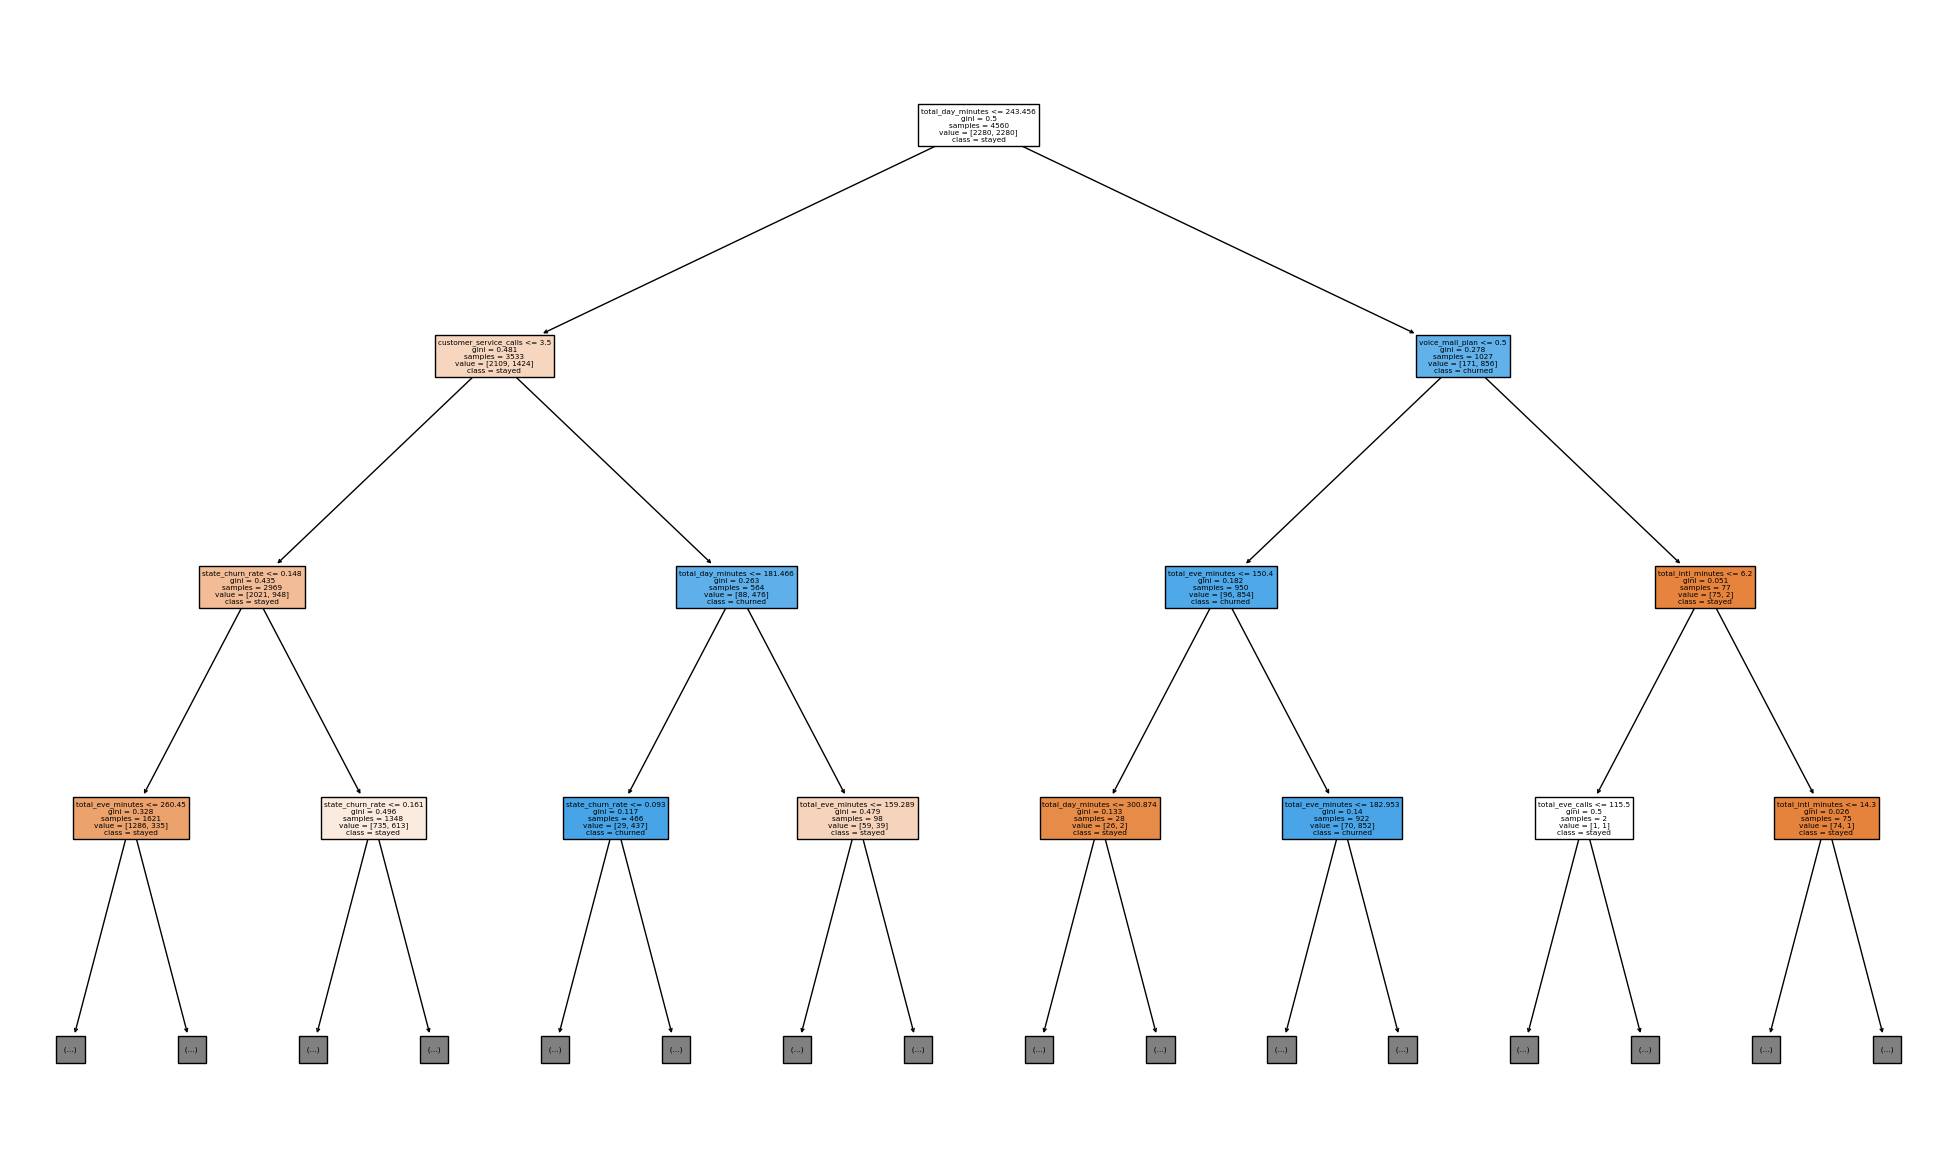

In [30]:
plt.figure(figsize=(25,15))
plot_tree(dt, feature_names=X.columns, class_names=['stayed','churned'], filled=True, max_depth=3)
plt.show()


In [31]:
#code for decision tree
customer_service_calls = 5
international_plan = 1
total_day_minutes = 250
voice_mail_plan = 0
number_vmail_messages = 0

if customer_service_calls >= 4:
    prediction = "predict churn"
elif international_plan == 1 and total_day_minutes >= 200:
    prediction = "predict churn"
elif voice_mail_plan == 0 and number_vmail_messages == 0:
    prediction = "higher churn risk"
else:
    prediction = "no churn"

print(prediction)

predict churn


predict churn
rules for the model:

If customer_service_calls ≥ 4 → predict churn.

Else if international_plan = 1 and total_day_minutes ≥ 200 → predict churn.

Else if voice_mail_plan = 0 and number_vmail_messages = 0 → higher churn risk.

II.LOGISTIC REGRESSION COEFFICIENTS

5.BUSINESS EVALUATION AND MODEL COMPARISON
  :CONFUSION MATRICES

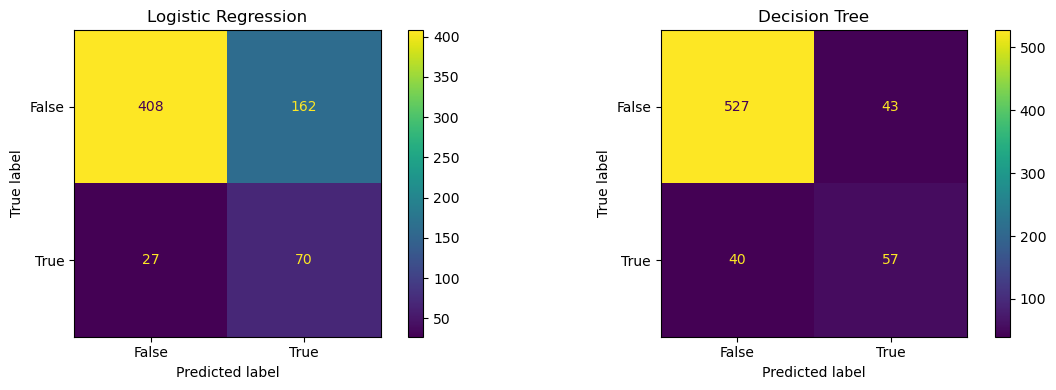

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0])
axes[0].set_title("Logistic Regression")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=axes[1])
axes[1].set_title("Decision Tree")
plt.tight_layout()
plt.show()

interpretation:
Logistic Regression has lower precision for churn (0.30) but good recall (0.72), making it better for identifying most at-risk customers.

Decision Tree has better overall accuracy (88%) and higher precision for churn (0.57), but slightly lower recall (0.59).

Recommendation: Use Logistic Regression for churn probability scoring; use Decision Tree for rule-based alerts ( if service calls ≥ 4 → flag for retention).

6.BUSINESS INSIGHTS (EDA)

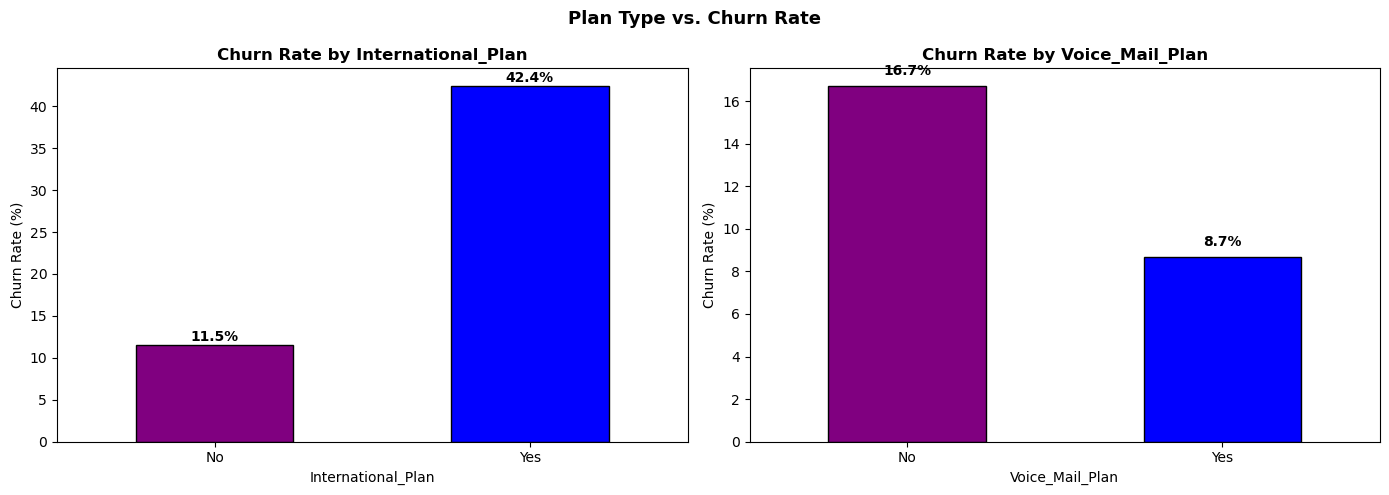

In [42]:
#churn vs customer service call
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['international_plan', 'voice_mail_plan']):
    churn_rate = df.groupby(col)['churn'].mean() * 100
    churn_rate.index = ['No', 'Yes']
    churn_rate.plot(kind='bar', ax=axes[i], color=['purple', 'blue'], edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col.title()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col.title())
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=0)
    for j, v in enumerate(churn_rate):
        axes[i].text(j, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Plan Type vs. Churn Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Interpretation:
Churn rate spikes sharply after 4+ customer service calls (over 60% churn for 5+ calls). This is the strongest single indicator of churn and should trigger immediate retention outreach.

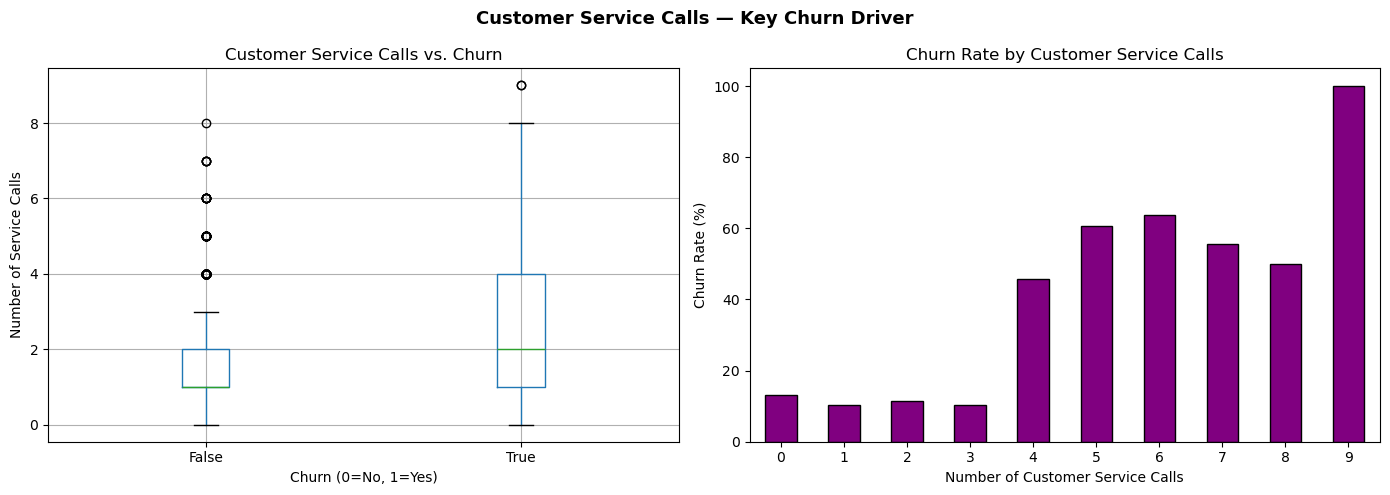

Churn rate by service call count:
customer_service_calls
0     13.2
1     10.3
2     11.5
3     10.3
4     45.8
5     60.6
6     63.6
7     55.6
8     50.0
9    100.0
Name: churn, dtype: float64


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
df.boxplot(column='customer_service_calls', by='churn', ax=axes[0])
axes[0].set_title('Customer Service Calls vs. Churn')
axes[0].set_xlabel('Churn (0=No, 1=Yes)')
axes[0].set_ylabel('Number of Service Calls')

# Bar chart: churn rate by number of service calls
churn_by_calls = df.groupby('customer_service_calls')['churn'].mean() * 100
churn_by_calls.plot(kind='bar', ax=axes[1], color='purple', edgecolor='black')
axes[1].set_title('Churn Rate by Customer Service Calls')
axes[1].set_xlabel('Number of Customer Service Calls')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Customer Service Calls — Key Churn Driver', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Churn rate by service call count:")
print(churn_by_calls.round(1))

Interpretation:
Customers with an international plan churn at nearly 3x the rate of those without.

Customers without a voicemail plan churn more than twice as often, suggesting voicemail may increase engagement and loyalty.

LOGISTIC REGRESSION COEFFICIENTS

In [32]:
coeffs = pd.Series(lr.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print("Top 5 features by absolute coefficient:")
print(coeffs.head(5))


Top 5 features by absolute coefficient:
voice_mail_plan          -2.126718
number_vmail_messages     1.550486
total_day_minutes         0.776701
customer_service_calls    0.766417
state_churn_rate          0.541223
dtype: float64


INTERPRETATION


Positive coefficient → increases churn probability ( customer_service_calls, international_plan).

Negative coefficient → decreases churn probability ( voice_mail_plan, total_night_minutes).


7.BUSINESS RECOMMENDATIONS

Based on the models, SyriaTel should:

I.Alert retention team when a customer makes >3 customer service calls in a month.

II.Offer loyalty discounts to customers with an international plan and high daytime minutes (>200 min).

III.Encourage voicemail plan adoption – customers without voicemail churn at a significantly higher rate.

IV.Build a simple probability dashboard – score all active customers weekly using the Logistic Regression model (because it gives well-calibrated probabilities).

V.Experiment with intervention thresholds – instead of 0.5, use a threshold that maximizes savings ( target top 20% of churn scores).
